<a href="https://colab.research.google.com/github/drmuruga/ocd-virtual-brain/blob/main/01_setup_and_connectome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/drmuruga/ocd-virtual-brain.git
%cd ocd-virtual-brain
!pip install -q -r requirements.txt

from google.colab import drive
drive.mount('/content/drive')

Cloning into 'ocd-virtual-brain'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 20 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 7.98 KiB | 1.14 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/ocd-virtual-brain/ocd-virtual-brain
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
from neurolib.utils.loadData import Dataset
ds = Dataset("hcp")
print("Connectome shape:", ds.Cmat.shape)
print("Number of brain regions:", ds.Cmat.shape[0])

Connectome shape: (80, 80)
Number of brain regions: 80


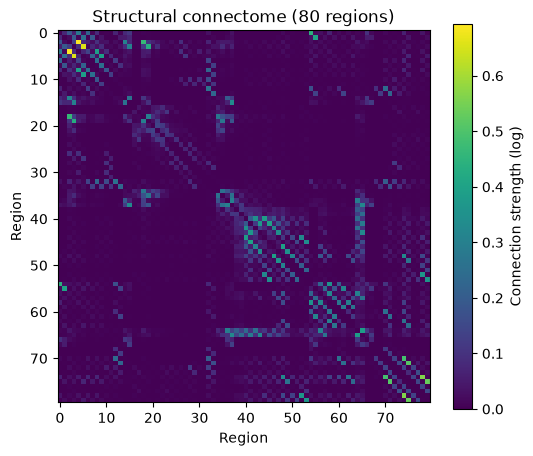

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 5))
plt.imshow(np.log1p(ds.Cmat), cmap="viridis")
plt.colorbar(label="Connection strength (log)")
plt.title("Structural connectome (80 regions)")
plt.xlabel("Region"); plt.ylabel("Region")
plt.show()

In [3]:
from neurolib.models.hopf import HopfModel

model = HopfModel(Cmat=ds.Cmat, Dmat=ds.Dmat)
model.params["duration"] = 5 * 60 * 1000   # 5 minutes of brain activity, in ms
model.params["K_gl"] = 0.6                 # global coupling: how strongly regions talk
model.params["sigma_ou"] = 0.14            # background noise

model.run(chunkwise=True, bold=True)       # also simulate fMRI (BOLD) signal
print("Simulated fMRI shape:", model.BOLD.BOLD.shape)

Simulated fMRI shape: (80, 150)


Similarity to real brains: 0.09


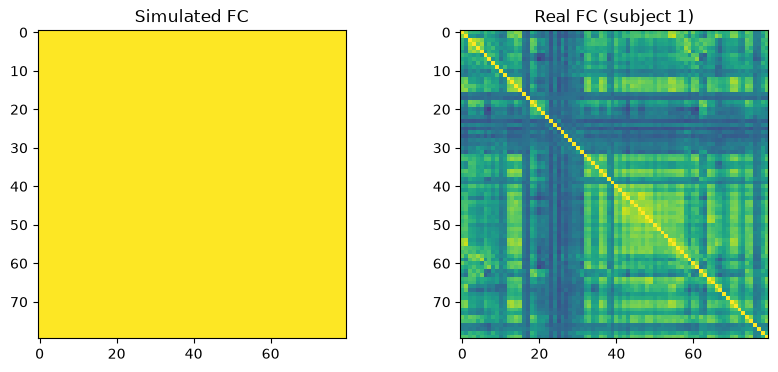

In [4]:
import neurolib.utils.functions as func

sim_fc = func.fc(model.BOLD.BOLD[:, 5:])   # skip the first few warm-up samples
scores = [func.matrix_correlation(sim_fc, real_fc) for real_fc in ds.FCs]
print(f"Similarity to real brains: {np.mean(scores):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(sim_fc, vmin=-0.5, vmax=1); ax[0].set_title("Simulated FC")
ax[1].imshow(ds.FCs[0], vmin=-0.5, vmax=1); ax[1].set_title("Real FC (subject 1)")
plt.show()

K_gl = 0.0  ->  similarity = -0.040
K_gl = 0.1  ->  similarity = 0.008
K_gl = 0.2  ->  similarity = 0.043
K_gl = 0.4  ->  similarity = 0.088
K_gl = 0.6  ->  similarity = 0.124
K_gl = 0.8  ->  similarity = 0.141
K_gl = 1.0  ->  similarity = 0.156
K_gl = 1.5  ->  similarity = 0.168
Best coupling: 1.5


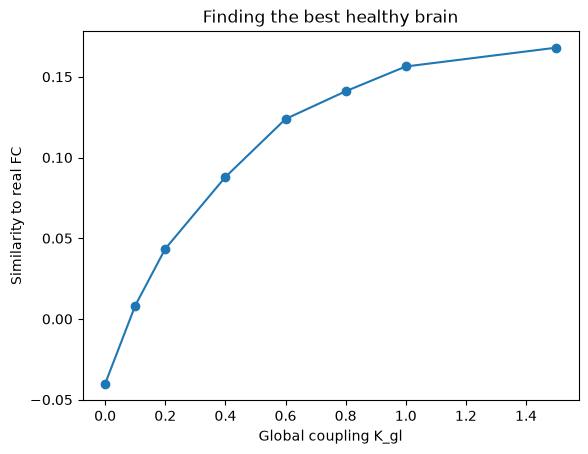

In [5]:
results = []
for K in [0.0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5]:
    model = HopfModel(Cmat=ds.Cmat, Dmat=ds.Dmat)
    model.params["duration"] = 5 * 60 * 1000
    model.params["a"] = -0.02          # near the tipping point, not self-oscillating
    model.params["K_gl"] = K
    model.params["sigma_ou"] = 0.14
    model.run(chunkwise=True, bold=True)

    sim_fc = func.fc(model.BOLD.BOLD[:, 5:])
    score = np.nanmean([func.matrix_correlation(sim_fc, real_fc) for real_fc in ds.FCs])
    results.append((K, score))
    print(f"K_gl = {K:.1f}  ->  similarity = {score:.3f}")

best_K = max(results, key=lambda r: r[1])[0]
print("Best coupling:", best_K)

plt.plot([r[0] for r in results], [r[1] for r in results], "o-")
plt.xlabel("Global coupling K_gl"); plt.ylabel("Similarity to real FC")
plt.title("Finding the best healthy brain")
plt.show()